# **Machine Learning**

This dataset contains booking information about City Hotels and Resorts and includes all the booking details.

The aim of this project is to predict and identify whether a Hotel Booking will be cancelled or stay confirmed using Machine Learning Algorithms.

**Dataset**: Kaggle Dataset

**Link to Dataset:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data

#**IMPORTING LIBRARIES**






In [1]:
# Importing Pandas and NumPy for handling the DataFrames and Numerical Arrays, respectively.
import pandas as pd
import numpy as np
# Importing Matplotlib and Seaborn to use in Exploratory Data Analysis(EDA) for Data Visualization.
import matplotlib.pyplot as plt
import seaborn as sns
#Importing train_test_split and StandardScaler to split Data into Train, Test Subsets and to standardize the features, respectively.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Importing accuracy_score, classification_report, confusion_matrix to evaluate performance, provide text summary of model's performance and for correct and incorrect predictions, respectively.
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
#Importing These Machine Learning Algorithms for training purpose and to compare the different types of Classification Algorithms.
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# **LOADING THE DATASET**

In [2]:
#Loading the Dataset hotel_bookings.csv into Pandas DataFrame and then display the First 5 Rows of the Dataset for Column Headers and Data Types verification.
df=pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# **DATA EXPLORATION**

## **Describing the Dataset**

In [3]:
# This is a method from the Pandas Library and it is used to describe the summary of statistics for all the 32 columns of the Dataset.
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## **Structure of the Dataset**

In [4]:
# This is a method which is gives the structure of the DataFrame of The Dataset and the method is from Pandas Library.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## **Size of the Dataset**

In [5]:
# This gives the Dimensions of The DataFrame (Rows,Columns) in the Dataset and it is from Pandas Library.
## Here, (11930,32) represents 119,390 rows and 32 columns.
df.shape

(119390, 32)

## **Counting Missing Values Per Column In The Dataset**

In [6]:
# This is the Pandas Function which is used to count the missing values per column.
df.isnull().sum()


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


## **Counting The Total Missing Values Across All The Columns Of The Dataset**

In [7]:
# This is also a Pandas Function which is used to give the total count of the missing values across all the columns of the Dataset.
## Here, the output is np.int64(129425) which means the total number(count) of missing values in the Dataset is 129,425 values.
df.isnull().sum().sum()

np.int64(129425)

## **Checking For Duplicate Records (Rows) In The Dataset**

In [8]:
# Here, this is a Pandas Function to check and count the total number of Duplicate Records, also called as Rows, in the Dataset used.
## The output here is np.int64(31994) which means there are 31,994 duplicate records.
df.duplicated().sum()

np.int64(31994)

## **Counting The Confirmed Reservations and Cancellations of Hotel Bookings In The Dataset**

In [9]:
# Counting the Confirmed Reservations and Cancellations in the Dataset
## Here, in the output, 0 represents the Confirmed Booking and 1 represents the Cancelled Booking.
### The output here shows that in the Dataset, there are 75,166 Confirmed Bookings and 44,224 Cancelled Bookings.
hotel_bookings_count=df['is_canceled'].value_counts()
print("The Count of Hotel Bookings is:",hotel_bookings_count)

The Count of Hotel Bookings is: is_canceled
0    75166
1    44224
Name: count, dtype: int64


## **Visualization of Data Distribution of the Dataset**

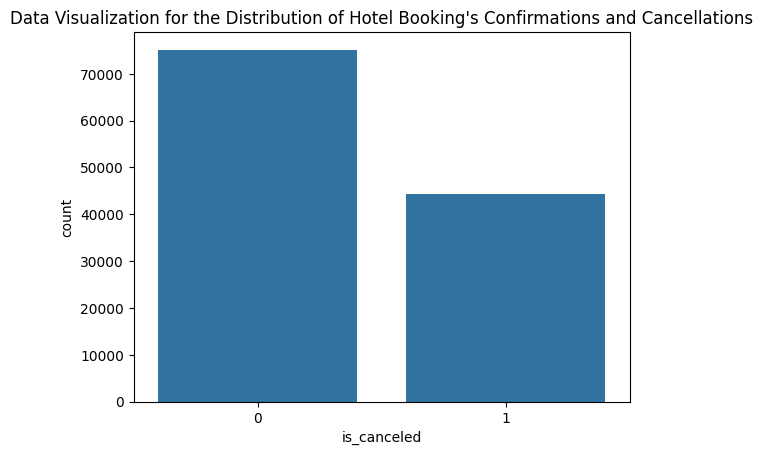

In [10]:
# Here, the plot (Bar Chart) shows the Visualizations of the distribution of both Confirmed Bookings and Cancelled Bookings of the Hotel in the Dataset.
# 0 represents the Confirmed Bookings (75166 Bookings) and 1 represents the Cancelled Bookings (44224 Bookings).
sns.countplot(x='is_canceled',data=df)
plt.title("Data Visualization for the Distribution of Hotel Booking's Confirmations and Cancellations")
plt.show()

## **Comparison Between Lead Time and Booking Cancellation of The Dataset**

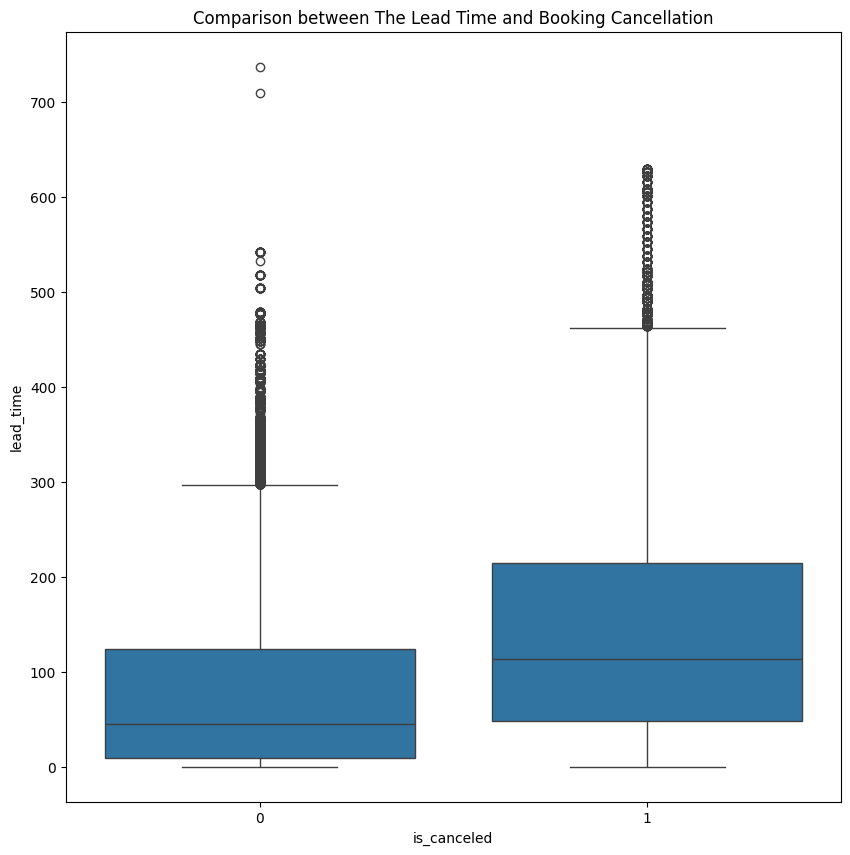

In [11]:
# Here, this is a plot which displays the Data Visualization for comparison between the Lead Time of Booking and Cancellation Time from the Booking.
## Lead Time is estimated time between the Guests' arrival date and the booking date. This is to predict when is the booking likely to get cancelled or stay confirmed.
### Output shows that Canceled Bookings have have a high lead time (around 80-90days) when compared to Confirmed Bookings (around 30-40 days).
plt.figure(figsize=(10,10))
sns.boxplot(x='is_canceled', y='lead_time',data=df)
plt.title("Comparison between The Lead Time and Booking Cancellation")
plt.show()

# **DATA PREPROCESSING**

## **Displaying The First 5 Rows of Duplicate Records (Rows) In The Dataset**

In [12]:
# Here, Pandas Method is used to check and verify if there are any existing Duplicate Record in the Dataset.
## Since the Dataset is very large, duplicate.head() is used, so that only the First 5 (by default) Duplicate Rows are displayed.
duplicate=df[df.duplicated()]
duplicate.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


## **Removing The Duplicate Records (Rows) In The Dataset**

In [13]:
# This is also a Pandas Method which is used to remove the Duplicate Records in the Dataset and this ensures of a clean Dataset.
## Printing the Success Message as well.
df=df.drop_duplicates()
print("Hello! Successfully Removed The Duplicate Records in the hotel_bookings.csv Dataset.")

Hello! Successfully Removed The Duplicate Records in the hotel_bookings.csv Dataset.


## **Verifying If Any Duplicate Records(Rows) Still Exists In The Dataset**

In [14]:
# Here, Pandas Method is used to check and verify if there are any existing Duplicate Records even after removing the Duplicates in the Previous Cell.
duplicate=df[df.duplicated()]
duplicate.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


## **Removing Columns with Data Leakage In The Dataset**

In [15]:
# There are two columns reservation_status and reservation_status_date has information which is available after booking.
## This information can lead to data leakage as the model will know about the booking outcome, especially Cancellation.
df=df.drop(['reservation_status','reservation_status_date'],axis=1)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1


## **Handling The Missing Values in The Dataset**

In [16]:
# In this Dataset, the NULL Values are displayed for these columns-agent, children, company and country.
## agent is filled with median value, children is filled with 0, company is removed due to many missing values and country is filled with most frequent value
### Dataset is checked again to verify if the missing values have been handled properly.
df['agent']=df['agent'].fillna(df['agent'].median())
df['children']=df['children'].fillna(0)
df=df.drop(['company'],axis=1)
df['country']=df['country'].fillna(df['country'].mode()[0])
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# **FEATURE ENGINEERING**

## **Encoding Categorical Varibles Using One-Hot Encoder In The Dataset**

In [17]:
# Converting Categorical Variables (text values) into Numerical Values using One-Hot Encoding method.
# New columns are created in the output.
# Note: After One-Hot Encoding, Dataset counts to 247 columns but dimensionality reduction is not used. Instead Ensemble Learning Models are used.
df=pd.get_dummies(df, drop_first=True)
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False


## **Defining the Input Feature and Target Variable In The Dataset**




In [18]:
# Here, the Dataset is being split into two that is Input Features(X) and Target Variable(Y).
# Here, Target Variable => is_canceled to represent if booking is cancelled or confirmed.
X=df.drop('is_canceled',axis=1)
y=df['is_canceled']
print("The Total Number of Features in this Dataset is:",X.shape[1])

The Total Number of Features in this Dataset is: 246


## **Train-Test Split For The Dataset**

In [19]:
# Here, the Dataset is split into 2 as Training Set and Testing Set which is used to train the model and evaluate model's performance on unseen/new data, respectively.
X_train, X_test, y_train, y_test=train_test_split(X, y,test_size=0.25,random_state=42)

## **Feature Scaling For The Dataset**

In [20]:
# Using StandardScaler to standardize the training set and testing set to make models perform the algorithms like KNN, Logistic Regression and SVM.
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# **MODEL TRAINING**

## **Decision Tree**

In [21]:
DecisionTree_Model=DecisionTreeClassifier(class_weight='balanced')
DecisionTree_Model.fit(X_train,y_train)
y_predict_DecisionTree=DecisionTree_Model.predict(X_test)
print("The Decision Tree Model is:")
print("The Predicted Values are:",y_predict_DecisionTree[:10])
print("The Actual Values are:",y_test.values[:10])
DecisionTree_accuracy=accuracy_score(y_test,y_predict_DecisionTree)
print("The Accuracy is:",DecisionTree_accuracy)


The Decision Tree Model is:
The Predicted Values are: [0 0 0 0 1 0 0 0 0 1]
The Actual Values are: [0 0 0 0 1 0 0 0 1 1]
The Accuracy is: 0.8043388713442263


## **K-Nearest Neighbors (KNN)**

In [22]:
KNN_Model=KNeighborsClassifier()
KNN_Model.fit(X_train_scaled, y_train)
y_predict_KNN=KNN_Model.predict(X_test_scaled)
print("The KNN Model is:")
print("The Predicted Values are:",y_predict_KNN[:10])
print("The Actual Values are:",y_test.values[:10])
KNN_accuracy=accuracy_score(y_test,y_predict_KNN)
print("The Accuracy is:",KNN_accuracy)

The KNN Model is:
The Predicted Values are: [0 0 1 0 1 1 0 0 1 1]
The Actual Values are: [0 0 0 0 1 0 0 0 1 1]
The Accuracy is: 0.7760538239736372


## **Logistic Regression**

In [23]:
LogisticRegression_Model=LogisticRegression(class_weight='balanced',max_iter=1000)
LogisticRegression_Model.fit(X_train_scaled,y_train)
y_predict_LogisticRegression=LogisticRegression_Model.predict(X_test_scaled)
print("The Logistic Regression Model is:")
print("The Predicted Values are:",y_predict_LogisticRegression[:10])
print("The Actual Values are:",y_test.values[:10])
LogisticRegression_accuracy=accuracy_score(y_test,y_predict_LogisticRegression)
print("The Accuracy is:",LogisticRegression_accuracy)

The Logistic Regression Model is:
The Predicted Values are: [0 0 0 0 1 1 0 0 1 1]
The Actual Values are: [0 0 0 0 1 0 0 0 1 1]
The Accuracy is: 0.7528033319602728


## **Naive Bayes**

In [24]:
NaiveBayes_Model=GaussianNB()
NaiveBayes_Model.fit(X_train_scaled,y_train)
y_predict_NaiveBayes=NaiveBayes_Model.predict(X_test_scaled)
print("The Naive Bayes Model is:")
print("The Predicted Values are:",y_predict_NaiveBayes[:10])
print("The Actual Values are:",y_test.values[:10])
NaiveBayes_accuracy=accuracy_score(y_test,y_predict_NaiveBayes)
print("The Accuracy is:",NaiveBayes_accuracy)

The Naive Bayes Model is:
The Predicted Values are: [1 0 1 1 1 1 1 1 1 1]
The Actual Values are: [0 0 0 0 1 0 0 0 1 1]
The Accuracy is: 0.36738523502219783


## **Random Forest**

In [25]:
RandomForest_Model=RandomForestClassifier(class_weight='balanced')
RandomForest_Model.fit(X_train,y_train)
y_predict_RandomForest=RandomForest_Model.predict(X_test)
print("The Random Forest Model is:")
print("The Predicted Values are:",y_predict_RandomForest[:10])
print("The Actual Values are:",y_test.values[:10])
RandomForest_accuracy=accuracy_score(y_test,y_predict_RandomForest)
print("The Accuracy is:",RandomForest_accuracy)

The Random Forest Model is:
The Predicted Values are: [0 0 0 0 0 0 0 0 0 1]
The Actual Values are: [0 0 0 0 1 0 0 0 1 1]
The Accuracy is: 0.8509771614261522


## **Support Vector Machine (SVM)**

In [26]:
SVM_Model=SVC(class_weight='balanced')
SVM_Model.fit(X_train_scaled,y_train)
y_predict_SVM=SVM_Model.predict(X_test_scaled)
print("The SVM Model is:")
print("The Predicted Values are:",y_predict_SVM[:10])
print("The Actual Values are:",y_test.values[:10])
SVM_accuracy=accuracy_score(y_test,y_predict_SVM)
print("The Accuracy is:",SVM_accuracy)

The SVM Model is:
The Predicted Values are: [0 0 0 1 1 1 0 0 1 1]
The Actual Values are: [0 0 0 0 1 0 0 0 1 1]
The Accuracy is: 0.7704242757105588


## **Comparison and Selection of Best Model For this Dataset**

For this Dataset, some Machine Learning Algorithms were used to train model and was evaluated to see which model is best for booking cancellation's prediction.

Once all models were trained, their performance was evaluated on Testing Sets to compare accuracy scores. When comparing, **Random Forest** Model obtained highest accuracy which equalled to 85.15%, followed by Decision Tree which equalled to 80.29%. Next accuracy score was KNN which was 77.66%, then SVM which was 77% and then Logistic Regression which is 75.28%. Naive Bayes was lowest performer model for this dataset whose accuracy score equalled to 36.73%.


## **Random Forest Model's Hyper-Parameter Tuning**

In [27]:
from sklearn.model_selection import GridSearchCV
search_parameter={'n_estimators': [100, 140],'max_depth': [8, 10, 20],'min_samples_split': [2, 5,7]}
grid_RandomForest=GridSearchCV(RandomForestClassifier(class_weight='balanced',random_state=42),search_parameter,cv=2,scoring='accuracy',n_jobs=-1)
grid_RandomForest.fit(X_train,y_train)
BestModelis_RandomForest_Model=grid_RandomForest.best_estimator_
print("The Best Parameters for Random Forest Model are:",grid_RandomForest.best_params_)
print("The Best Accuracy Score from Grid Search is:",grid_RandomForest.best_score_)

The Best Parameters for Random Forest Model are: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
The Best Accuracy Score from Grid Search is: 0.8094954599585245


# **MODEL ASSESSMENT**

In [28]:
y_predict_BestRandomForestModel=BestModelis_RandomForest_Model.predict(X_test)
print("The Optimized Random Forest Model is:")
print("The Predicted Values are:",y_predict_BestRandomForestModel[:10])
print("The Actual Values are:",y_test.values[:10])
BestRandomForestModel_accuracy=accuracy_score(y_test,y_predict_BestRandomForestModel)
print("The Final Optimized Accuracy is:",BestRandomForestModel_accuracy)

The Optimized Random Forest Model is:
The Predicted Values are: [0 0 0 0 1 0 0 0 1 1]
The Actual Values are: [0 0 0 0 1 0 0 0 1 1]
The Final Optimized Accuracy is: 0.8098768822371734


## **Visualization of Confusion Matrix**

This is the Visualization of the Confusion Matrix which compares the Predicted Booking Status with the Actual Booking Status.

It can be observed from the Confusion Matrix that number of bookings that were correctly predicted as not cancelled are 12736. Then, the number of bookings that were correctly predicted as cancelled are 4959.Then, the number of bookings that were predicted as cancelled but were actually not cancelled are 3174.The number of bookings that were predicted as not cancelled but were actually cancelled are 980.

The Predictions are successfully done and the First 5 Values are: [0 0 0 0 1]


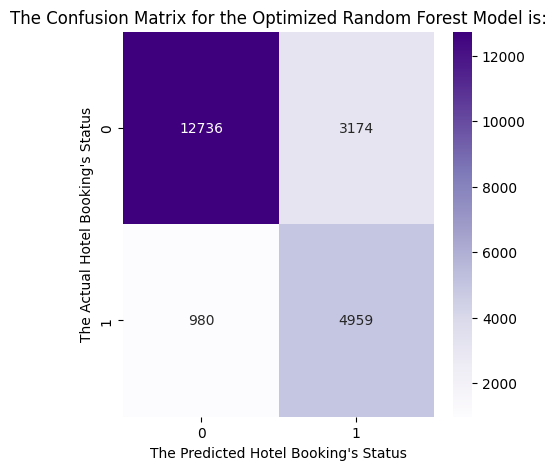

In [29]:
y_predict_BestRandomForest=BestModelis_RandomForest_Model.predict(X_test)
print("The Predictions are successfully done and the First 5 Values are:",y_predict_BestRandomForest[:5])
CM = confusion_matrix(y_test,y_predict_BestRandomForest)
plt.figure(figsize=(5,5))
sns.heatmap(CM,annot=True,fmt='d',cmap='Purples')
plt.title("The Confusion Matrix for the Optimized Random Forest Model is:")
plt.xlabel("The Predicted Hotel Booking's Status")
plt.ylabel("The Actual Hotel Booking's Status")
plt.show()

## **Classification Report**

In [30]:
print("The Classification Report for the Optimized Random Forest Model is:")
print(classification_report(y_test,y_predict_BestRandomForest))

The Classification Report for the Optimized Random Forest Model is:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     15910
           1       0.61      0.83      0.70      5939

    accuracy                           0.81     21849
   macro avg       0.77      0.82      0.78     21849
weighted avg       0.84      0.81      0.82     21849



## **Feature Information of This Dataset**

In [31]:
Feature_Information_Values = BestModelis_RandomForest_Model.feature_importances_
Feature_Information_Table = pd.DataFrame({
    'Hotel_Feature': X.columns,
    'Information_Score': Feature_Information_Values
})
Feature_Information_Table = Feature_Information_Table.sort_values(by='Information_Score', ascending=False)
print("The First 10 Most Informative Features for Hotel Cancellations are:")
print(Feature_Information_Table.head(10))

The First 10 Most Informative Features for Hotel Cancellations are:
                   Hotel_Feature  Information_Score
0                      lead_time           0.111920
168                  country_PRT           0.097116
13                         agent           0.073566
16   required_car_parking_spaces           0.072751
17     total_of_special_requests           0.063694
15                           adr           0.051295
215     market_segment_Online TA           0.047743
2       arrival_date_week_number           0.028150
1              arrival_date_year           0.027144
5           stays_in_week_nights           0.026504


**This project has analysed the Booking Demand of a Hotel and predicted the booking cancellations and confirmations using the Machine Learning Algorithms. Many models were trained and tested including the Decision Tree, KNN, Logistic Regression, Naive Bayes, Random Forest and SVM.**

**In Conclusion, the Random Forest Model obtained highest and best accuracy for performance and was best in terms of predicting Hotel Booking's Cancellations. This insight can help the Hotel's Reservation System to better manage the revenue and room allocation and predict the future trends of Booking cancellations using the pattern of the old data from the dataset.**



